<a href="https://colab.research.google.com/github/Rahel000/computer-vision-and-deep-learning/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
#Ambil dataset dari repo untuk dipakai disini

!git clone https://github.com/Rahel000/computer-vision-and-deep-learning.git
%cd computer-vision-and-deep-learning
!ls

Cloning into 'computer-vision-and-deep-learning'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (121/121), done.
remote: Total 122 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 1.14 MiB | 3.77 MiB/s, done.
Resolving deltas: 100% (11/11), done.
/content/computer-vision-and-deep-learning/computer-vision-and-deep-learning/computer-vision-and-deep-learning/computer-vision-and-deep-learning/computer-vision-and-deep-learning
fork			       metadata.csv  Transfer_Learning.ipynb
grafik_feature_extraction.png  README.md
grafik_perbandingan.png        spoon


In [24]:
#Buat mastiin GPU nya aktif sama liat datanya ada berapa

import torch, os

print("GPU aktif:", torch.cuda.is_available())
for kelas in ["spoon", "fork"]:
    print(kelas, "=", len(os.listdir(kelas)), "foto")

GPU aktif: True
spoon = 50 foto
fork = 50 foto


#Untuk bagi jadi 2 kelompok yaitu traning dan validation
Jadinya fotonya dipilih acak 40 sendok 40 garpu untuk training. Terus 10 sendok dan 10 garpu buat validasinya.

Seed=42 membuat foto akan selalu sama pengelompokannya. Jadi kalo hari ini foto 1 ada di train, maka selanjutnya akan terus begitu. Kecuali kalau seed=42 nya diubah, maka akan ada perubahan juga.

In [25]:
import os, random, shutil
random.seed(42)

kelas_list = ["spoon", "fork"]

for split in ["train", "val"]:
    for k in kelas_list:
        os.makedirs(f"data/{split}/{k}", exist_ok=True)

for k in kelas_list:
    files = sorted(f for f in os.listdir(k) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    random.shuffle(files)
    n_train = int(len(files) * 0.8)
    for i, f in enumerate(files):
        tujuan = "train" if i < n_train else "val"
        shutil.copy(f"{k}/{f}", f"data/{tujuan}/{k}/{f}")
    print(k, "-> train:", n_train, "| val:", len(files) - n_train)

spoon -> train: 40 | val: 10
fork -> train: 40 | val: 10


In [26]:
#Foto diubah dulu (Resize-ToTensor-Normalize)

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder("data/train", tf)
val_ds = datasets.ImageFolder("data/val", tf)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16)

print("Kelas:", train_ds.classes)
print("Jumlah train:", len(train_ds), "| val:", len(val_ds))

Kelas: ['fork', 'spoon']
Jumlah train: 80 | val: 20


In [27]:
#feature extraction

import torch
import torch.nn as nn

device = "cuda"

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False          # kunci semua

model.fc = nn.Linear(model.fc.in_features, 2)   # kepala baru: spoon / fork
model = model.to(device)

print("Model siap")

Model siap


#**Training & Validation**
Satu epoch = model melihat seluruh 80 foto latihan satu kali. Dilakukan 10 kali.

1. **Bagian Training (belajar)**
    
    **criterion** menghitung loss, yaitu seberapa salah tebakannya. Makin kecil makin bagus. **loss.backward()** untuk cari perbaikannya itu dinaikkan atau diturunkan agar loss mengecil. Lalu ada optimizer.step() dan zero_grad().

2. **Bagian Validation (uji)**
    
    Isinya tetap sama menebak, hitung loss, hitung benar juga. Tapi disini gaada perbaikan kaya **loss.backward()** dan **optimizer.step()**.

**hist** menyimpan angka tiap epoch, nanti dipakai untuk grafik.

In [28]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
mulai = time.time()

for epoch in range(10):
    # --- belajar ---
    model.train()
    loss_sum, benar = 0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        benar += (out.argmax(1) == y).sum().item()
    tr_loss, tr_acc = loss_sum / len(train_ds), benar / len(train_ds)

    # --- ujian ---
    model.eval()
    loss_sum, benar = 0, 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            benar += (out.argmax(1) == y).sum().item()
    va_loss, va_acc = loss_sum / len(val_ds), benar / len(val_ds)

    hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
    hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1:2d} | train acc {tr_acc:.2%} | val acc {va_acc:.2%} | val loss {va_loss:.3f}")

print(f"Waktu training: {time.time() - mulai:.1f} detik")

Epoch  1 | train acc 43.75% | val acc 65.00% | val loss 0.668
Epoch  2 | train acc 65.00% | val acc 60.00% | val loss 0.619
Epoch  3 | train acc 92.50% | val acc 70.00% | val loss 0.573
Epoch  4 | train acc 91.25% | val acc 75.00% | val loss 0.546
Epoch  5 | train acc 92.50% | val acc 85.00% | val loss 0.524
Epoch  6 | train acc 92.50% | val acc 85.00% | val loss 0.509
Epoch  7 | train acc 95.00% | val acc 85.00% | val loss 0.487
Epoch  8 | train acc 96.25% | val acc 85.00% | val loss 0.486
Epoch  9 | train acc 93.75% | val acc 80.00% | val loss 0.470
Epoch 10 | train acc 98.75% | val acc 80.00% | val loss 0.465
Waktu training: 7.2 detik


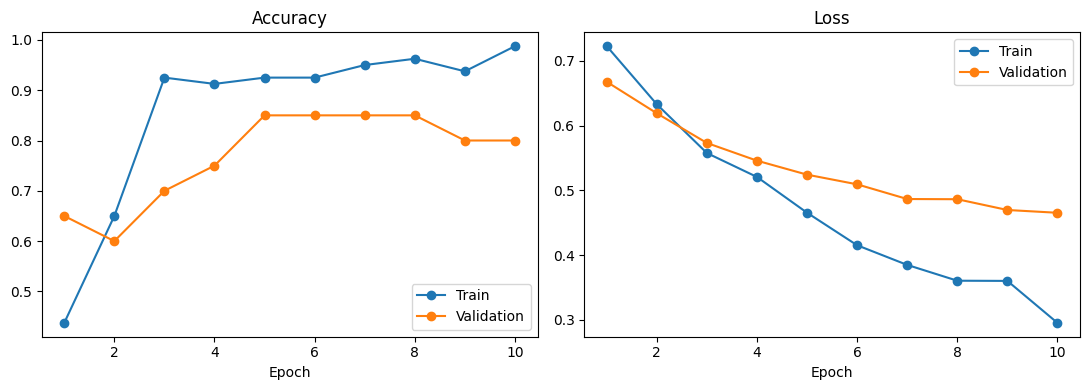

In [29]:
#Hanya menggambar isi hist jadi kurva
import matplotlib.pyplot as plt

ep = range(1, 11)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(ep, hist["train_acc"], marker="o", label="Train")
ax[0].plot(ep, hist["val_acc"], marker="o", label="Validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(ep, hist["train_loss"], marker="o", label="Train")
ax[1].plot(ep, hist["val_loss"], marker="o", label="Validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()

plt.tight_layout()
plt.savefig("grafik_feature_extraction.png", dpi=150)
plt.show()

In [41]:
# Latensi
x = torch.randn(1, 3, 224, 224).to(device)
model.eval()
with torch.no_grad():
    for _ in range(10):
        model(x)                      # pemanasan GPU
    torch.cuda.synchronize()
    mulai = time.time()
    for _ in range(100):
        model(x)
    torch.cuda.synchronize()
print(f"{(time.time() - mulai) / 100 * 1000:.1f} ms/foto")

6.4 ms/foto


In [32]:
from google.colab import files
files.download("grafik_feature_extraction.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>